In [2]:
import pandas as pd

df = pd.read_csv("../data/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# E-Commerce Sales Analytics

## Business Problem

Management has observed that sales are increasing, but profits are not increasing proportionally.

The goal of this analysis is to identify the key drivers affecting profitability and provide actionable business recommendations.

## Objectives

- Analyze sales trends over time
- Understand profit drivers
- Identify loss-making products
- Study customer purchasing behavior
- Analyze shipping efficiency
- Evaluate regional performance

In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df['Order Date']=pd.to_datetime(df['Order Date'])

df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [14]:
df['Shipping Days'] = (
    df['Ship Date']
    -
    df['Order Date']
).dt.days

In [15]:
df['Month']=df['Order Date'].dt.month

In [16]:
df['Year']=df['Order Date'].dt.year

In [18]:
df['Quarter']=df['Order Date'].dt.quarter

In [19]:
df['Profit Margin']=(
    df['Profit']
    /
    df['Sales']
)*100

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Days,Month,Year,Quarter,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,11,2016,4,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,11,2016,4,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,6,2016,2,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,10,2015,4,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,10,2015,4,11.25


In [21]:
monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()


monthly_sales

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

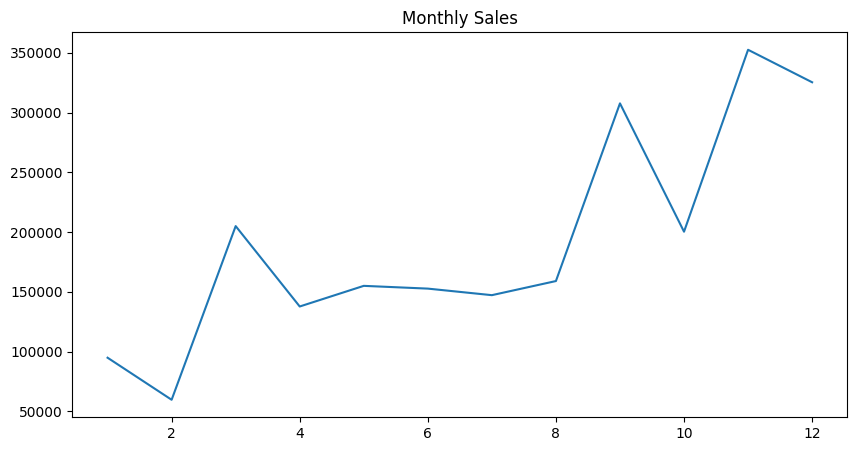

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(monthly_sales)

plt.title("Monthly Sales")

plt.show()

In [23]:
df['Profit'].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

In [24]:
loss_products = df.groupby(
'Product Name'
)['Profit'].sum()


loss_products=loss_products.sort_values()


loss_products.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [25]:
df.groupby(
'Category'
)[['Sales','Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


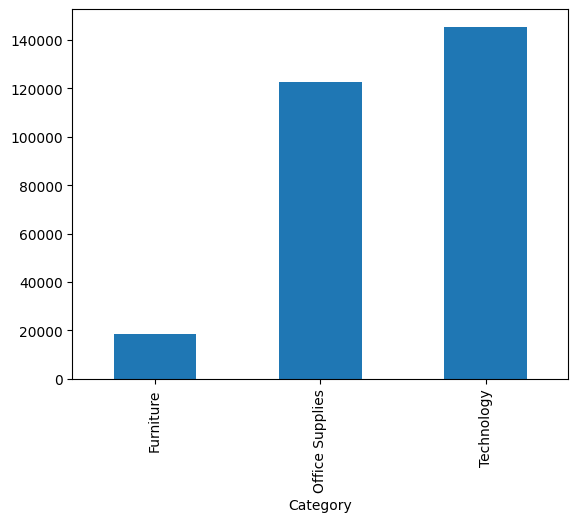

In [26]:
cat=df.groupby(
'Category'
)['Profit'].sum()

cat.plot.bar()

plt.show()

In [27]:
top_customers=df.groupby(
'Customer Name'
)['Sales'].sum()


top_customers.sort_values(
ascending=False
).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [28]:
df['Shipping Days'].mean()

np.float64(3.958174904942966)

In [29]:
df.groupby(
'Ship Mode'
)['Profit'].sum()

Ship Mode
First Class        48969.8399
Same Day           15891.7589
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64

In [30]:
df.groupby(
'Region'
)['Profit'].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

# Advanced Exploratory Data Analysis

In [31]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

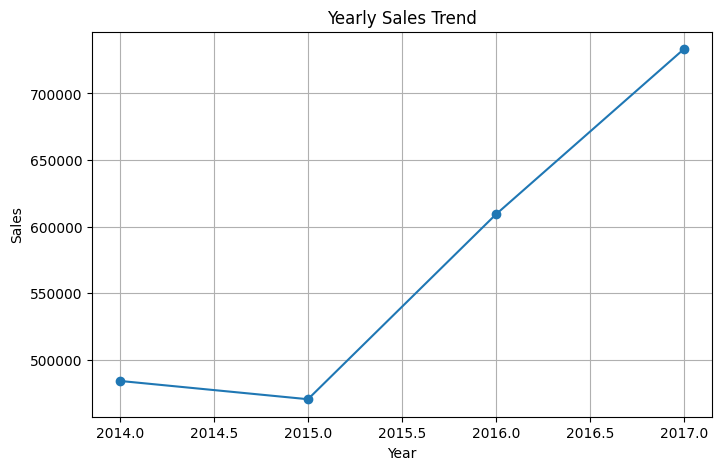

In [32]:
plt.figure(figsize=(8,5))
yearly_sales.plot(marker='o')
plt.title("Yearly Sales Trend")
plt.ylabel("Sales")
plt.grid()
plt.show()

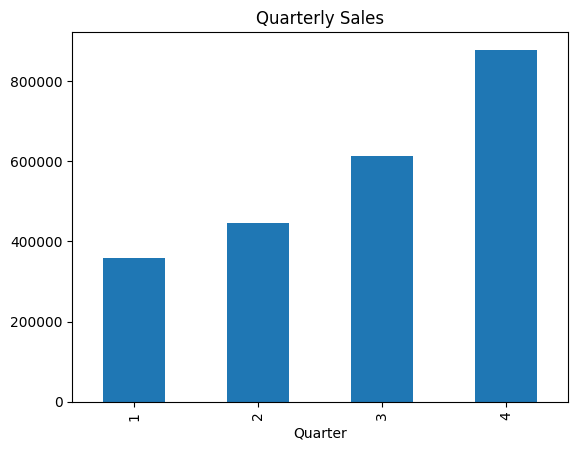

In [33]:
quarterly = df.groupby('Quarter')['Sales'].sum()

quarterly.plot(kind='bar')

plt.title("Quarterly Sales")
plt.show()

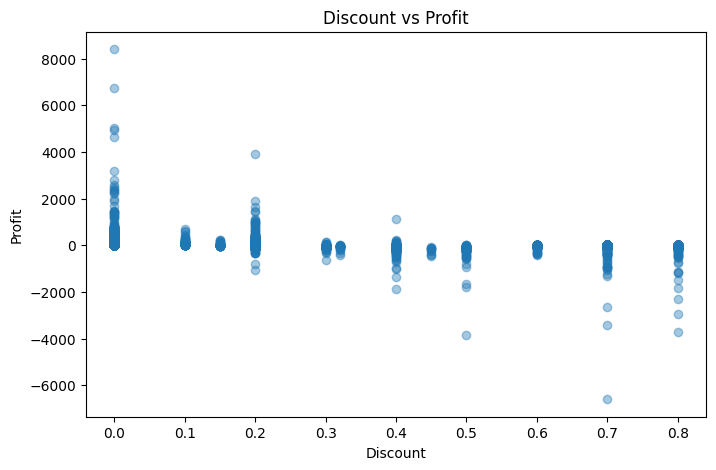

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'],
            df['Profit'],
            alpha=.4)

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.title("Discount vs Profit")

plt.show()

In [35]:
discount_analysis = df.groupby(
'Discount'
)['Profit'].mean()

discount_analysis

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

In [36]:
segment_analysis = df.groupby(
'Segment'
)[['Sales','Profit']].sum()

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


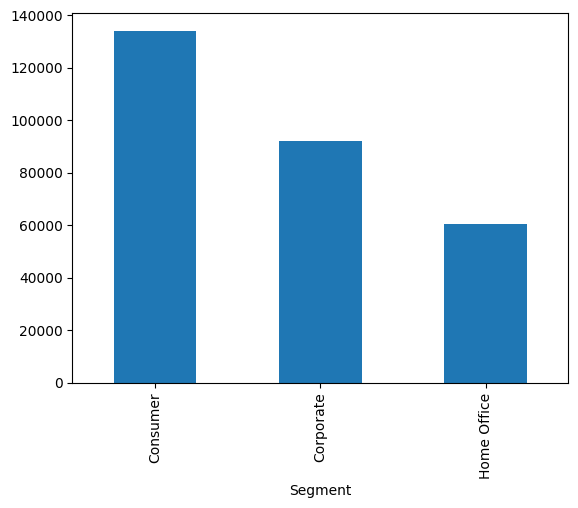

In [37]:
segment_analysis['Profit'].plot(
kind='bar'
)

plt.show()

In [38]:
top_states = df.groupby(
'State'
)['Profit'].sum()

top_states.sort_values(
ascending=False
).head(10)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

In [39]:
top_states.sort_values().head(10)

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

In [40]:
corr=df[[
'Sales',
'Profit',
'Discount',
'Quantity',
'Shipping Days'
]].corr()

corr

,Sales,Profit,Discount,Quantity,Shipping Days
Sales,1.000000,0.479064,-0.028190,0.200795,-0.007354
Profit,0.479064,1.000000,-0.219487,0.066253,-0.004649
Discount,-0.028190,-0.219487,1.000000,0.008623,0.000408
Quantity,0.200795,0.066253,0.008623,1.000000,0.018298
Shipping Days,-0.007354,-0.004649,0.000408,0.018298,1.000000


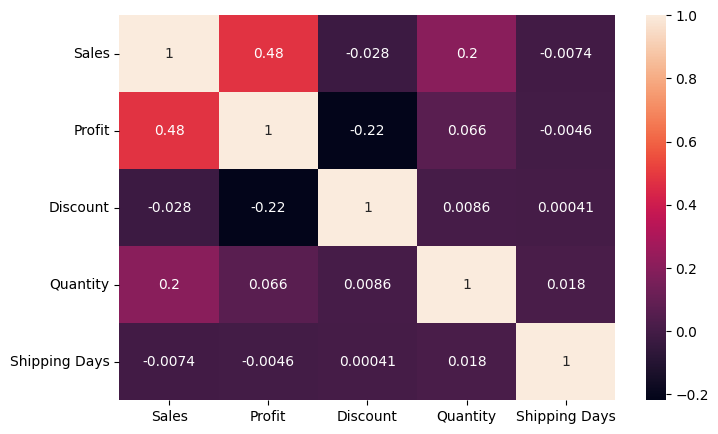

In [41]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
corr,
annot=True
)

plt.show()

In [42]:
customer=df.groupby(
'Customer Name'
).agg(

sales=('Sales','sum'),

profit=('Profit','sum'),

orders=('Order ID','count')

)

customer.head()

,sales,profit,orders
Customer Name,,,
Aaron Bergman,886.156,129.3465,6
Aaron Hawkins,1744.700,365.2152,11
Aaron Smayling,3050.692,-253.5746,10
Adam Bellavance,7755.620,2054.5885,18
Adam Hart,3250.337,281.1890,20


In [43]:
customer.sort_values(
'profit',
ascending=False
).head(10)

,sales,profit,orders
Customer Name,,,
Tamara Chand,19052.218,8981.3239,12
Raymond Buch,15117.339,6976.0959,18
Sanjit Chand,14142.334,5757.4119,22
Hunter Lopez,12873.298,5622.4292,11
Adrian Barton,14473.571,5444.8055,20
Tom Ashbrook,14595.620,4703.7883,10
Christopher Martinez,8954.020,3899.8904,10
Keith Dawkins,8181.256,3038.6254,28
Andy Reiter,6608.448,2884.6208,9


In [44]:
customer.sort_values(
'profit'
).head(10)

,sales,profit,orders
Customer Name,,,
Cindy Stewart,5690.055,-6626.3895,9
Grant Thornton,9351.212,-4108.6589,6
Luke Foster,3930.509,-3583.9770,16
Sharelle Roach,3233.481,-3333.9144,9
Henry Goldwyn,3247.642,-2797.9635,17
Nathan Cano,2218.990,-2204.8072,14
Sean Braxton,8057.891,-2082.7451,17
Sean Miller,25043.050,-1980.7393,15
Christine Phan,5888.275,-1850.3029,15
